In [18]:
 
# ## Adaptation of Hunstville Ignition Energy Paper for Turbopump TCA


import cantera as ct
import CoolProp as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

PSI2PA = 6894.76 # psi to pa
R2K = 0.555556 # Rankine to Kelvin
BTU2J = 1055.06 # BTU to J
LBM2KG = 0.453592 # lbm to kg


# Torch
fuel_torch = "hydrogen"
ox_torch = "oxygen"
mech_torch = "h2_sandiego.yaml" # torch reaction mechanism (H2)
OF_torch = 1
pc_torch = 300 * PSI2PA

# MCA
fuel = "n-Dodecane"
ox = "oxygen"
mech_MCA = "A2NTC_skeletal.yaml" # MCA reaction mechanism (Jet-A)
OF_MCA = 2.2
mdot_main = 20 * LBM2KG


T1_f = 298
T2_f = 500
T1_ox = 90
T2_ox = 500
Pc = 500 * PSI2PA

OF_Set = np.arange(1,50,0.1)
energy = []
temp = []
mdot = []
for OF_torch in OF_Set:
# ### Find Change in enthalpy required to reach Autoigniton Temperature for MCA Propellants


    h1_ox = cp.CoolProp.PropsSI("H", "T", T1_ox, "P", Pc, ox)
    h2_ox = cp.CoolProp.PropsSI("H", "T", T2_ox, "P", Pc, ox)
    h1_f = cp.CoolProp.PropsSI("H", "T", T1_f, "P", Pc, fuel)
    h2_f = cp.CoolProp.PropsSI("H", "T", T2_f, "P", Pc, fuel)

    dh_f = h2_f - h1_f
    dh_ox = h2_ox - h1_ox

    df = pd.DataFrame([dh_f*1e-6, dh_ox*1e-6], [fuel, ox], columns=["Delta h [MJ/kg]"])

    dh_mix = (1/(OF_MCA+1)) * dh_f + (OF_MCA/(OF_MCA+1)) * dh_ox # J/kg
    print("MCA Propellants: \n State 1: Injection \n State 2: Autoignition Temperature\n")
    print(df)
    print(f"\nMass Averaged dh: {dh_mix * 10**-6:0.3f} [MJ/kg]")


    # function to get masss averaged chemical potential of mixture 
    def mass_avg_chem_pot(mixture):
        mu = mixture.chemical_potentials      # J/kmol
        W  = mixture.molecular_weights        # kg/kmol
        Y  = mixture.Y                        # mass fractions
        return np.dot(Y, mu / W)              # J/kg mixture


    # find difference in chemical potentials in torch reaction to find energy released from reaction
    torch_rxn = ct.Solution(mech_torch)
    torch_rxn.TPY = 298, pc_torch, {"O2": OF_torch/(OF_torch+1), "H2":(1/(OF_torch+1)) } 

    # get starting chemical potentials, equillibriate reaction and find difference
    pre_rxn = mass_avg_chem_pot(torch_rxn)
    torch_rxn.equilibrate("HP")
    post_rxn = mass_avg_chem_pot(torch_rxn)

    combustion_energy_torch = np.abs(post_rxn - pre_rxn)


    print("Torch Energy Release:\n")
    print(f"Flame Temp: {torch_rxn.T:0.1f} [K]")
    print(f"Combustion Energy: {combustion_energy_torch* 10**-6:0.3f} [MJ/kg]")


    # same process for MCA Combustion energy
    # find difference in chemical potentials in torch reaction to find energy released from reaction
    MCA_rxn = ct.Solution(mech_MCA)
    MCA_rxn.TPY = T2_f, Pc, {"O2": OF_MCA/(OF_MCA+1), "POSF10325":(1/(OF_MCA+1)) } 

    # get starting chemical potentials, equillibriate reaction and find difference
    pre_rxn = mass_avg_chem_pot(MCA_rxn)
    MCA_rxn.equilibrate("HP")
    post_rxn = mass_avg_chem_pot(MCA_rxn)

    combustion_energy_MCA = np.abs(post_rxn - pre_rxn)

    print("MCA Energy Release:\n")
    print(f"Flame Temp: {MCA_rxn.T:0.1f} [K]")
    print(f"Combustion Energy: {combustion_energy_MCA* 10**-6:0.3f} [MJ/kg]")


    # Compute percent of MCA that needs to ignite for chain reaction
    x = dh_mix/combustion_energy_MCA 
    P_ig = mdot_main * x * dh_mix

    print(f"{x*100:0.3f}% of mdot_main to cause chain reaction")
    print(f"Torch Power Required: {P_ig*10**-3:0.3f} [kW]")


    nu = 0.2 # Heat Transfer Efficiency from torch exhaust to MCA Propellants
    mdot_torch = P_ig / (combustion_energy_torch * nu)
    mdot_torch_perfect = P_ig / (combustion_energy_torch)


    print(f"Assuming Perfect Heat Transfer:")
    print(f" mdot Torch: {mdot_torch_perfect:0.5f} [kg/s]\n")

    print(f"Assuming Heat Transfer Efficiency of {nu*100:0.2f}%")
    print(f" mdot Torch: {mdot_torch:0.5f} [kg/s]")

    energy.append(combustion_energy_torch * 1e-6)
    temp.append(torch_rxn.T)
    mdot.append(mdot_torch_perfect)
    clear_output()


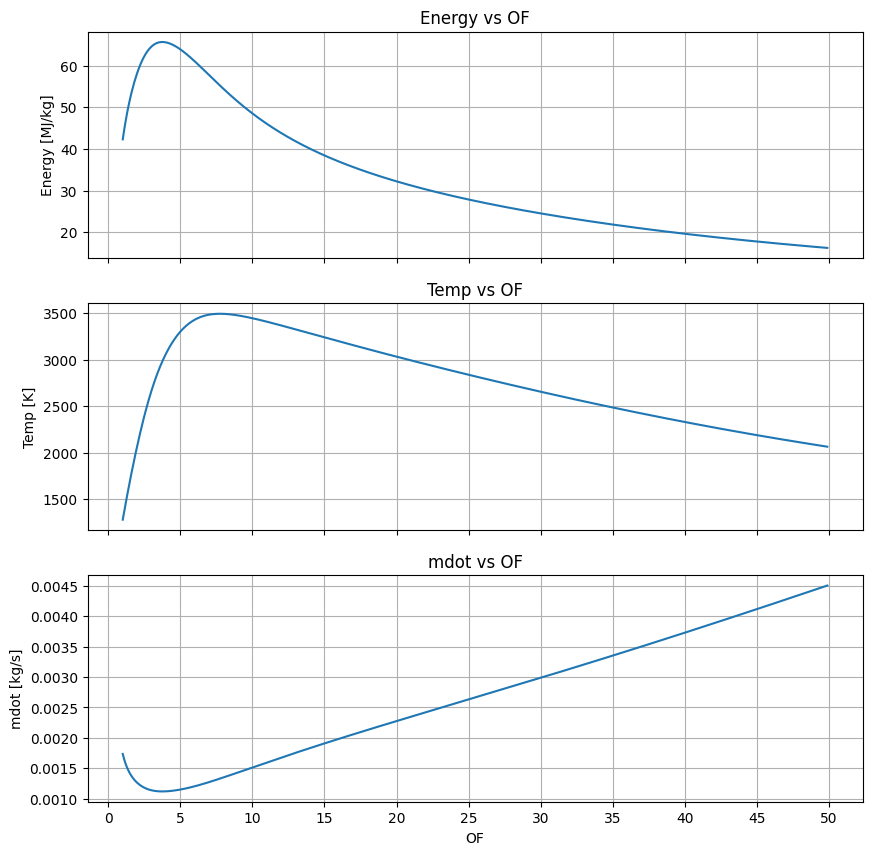

In [22]:
x = OF_Set.transpose()

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(x, energy)
axs[0].set_ylabel("Energy [MJ/kg]")
axs[0].set_title("Energy vs OF")
axs[0].grid(True)

axs[1].plot(x, temp)
axs[1].set_ylabel("Temp [K]")
axs[1].set_title("Temp vs OF")
axs[1].grid(True)

axs[2].plot(x, mdot)
axs[2].set_ylabel("mdot [kg/s]")
axs[2].set_title("mdot vs OF")
axs[2].set_xlabel("OF")
axs[2].set_xticks(range(0,51,5))
axs[2].grid(True)


plt.savefig('OF_Study.png')
